In [1]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


## Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib

In [3]:
# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Load and discover the dataset

In [28]:
df = pd.read_csv("/kaggle/input/human-vital-sign-dataset/human_vital_signs_dataset_2024.csv")
df.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Respiratory Rate          200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5   Oxygen Saturation         200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

In [30]:
df.describe()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,100010.500000,79.533747,15.489451,36.748353,97.504372,124.437971,79.499625,53.446275,74.996419,1.750031,0.099970,44.938346,25.003625,94.479074
std,57740.944759,11.552894,2.294472,0.433290,1.442598,8.656946,5.757248,20.786802,14.471502,0.144554,0.028861,10.404945,6.447143,4.797891
min,1.000000,60.000000,12.000000,36.000004,95.000007,110.000000,70.000000,18.000000,50.000156,1.500001,0.050000,21.000000,12.505974,83.333333
25%,50005.750000,70.000000,13.000000,36.372613,96.256859,117.000000,75.000000,35.000000,62.423615,1.624777,0.074955,37.000000,20.134367,91.000000
50%,100010.500000,80.000000,15.000000,36.747741,97.509629,124.000000,79.000000,53.000000,74.977169,1.750478,0.099988,45.000000,24.320776,94.333333
75%,150015.250000,90.000000,17.000000,37.123003,98.755722,132.000000,84.000000,71.000000,87.539510,1.875310,0.124917,53.000000,29.187169,98.000000
max,200020.000000,99.000000,19.000000,37.499992,99.999963,139.000000,89.000000,89.000000,99.999765,1.999997,0.149999,69.000000,44.376487,105.666667


In [31]:
df.isna().sum()

Patient ID                  0
Heart Rate                  0
Respiratory Rate            0
Timestamp                   0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
dtype: int64

In [32]:
df.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

In [33]:
df.value_counts('Risk Category')     # Balanced data

Risk Category
High Risk    105115
Low Risk      94905
Name: count, dtype: int64

<Axes: ylabel='count'>

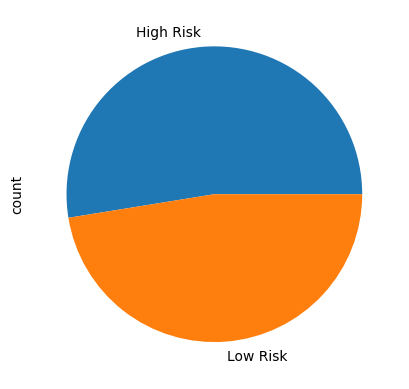

In [34]:
df['Risk Category'].value_counts().plot.pie()

In [35]:
df['Risk Category'].unique()

array(['High Risk', 'Low Risk'], dtype=object)

## Prepare data for training

In [27]:
df.columns

Index(['Heart Rate', 'Respiratory Rate', 'Body Temperature',
       'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Risk Category'],
      dtype='object')

In [36]:
df = df.drop_duplicates()
df = df.drop(['Timestamp', 'Patient ID', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP',"Respiratory Rate",'Age', 'Gender', 'Weight (kg)',
       'Height (m)'], axis='columns')
df.head(10)

,Heart Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Risk Category
0,60,36.861707,95.702046,124,86,High Risk
1,63,36.511633,96.689413,126,84,High Risk
2,63,37.052049,98.508265,131,78,Low Risk
3,99,36.654748,95.011801,118,72,High Risk
4,69,36.975098,98.623792,138,76,High Risk
5,79,36.884979,95.987129,130,70,Low Risk
6,81,37.273640,99.456716,118,84,High Risk
7,96,36.852633,97.124125,135,77,High Risk
8,83,36.044191,98.584497,111,84,Low Risk
9,66,36.957178,97.916267,131,77,High Risk


In [37]:
label_encoder = LabelEncoder()
# df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Risk Category'] = label_encoder.fit_transform(df['Risk Category'])

In [14]:
# Apply feature weights
# feature_weights = {
#     'Systolic Blood Pressure': 0.18,
#     'Diastolic Blood Pressure': 0.15,
#     'Oxygen Saturation': 0.15,
#     'Heart Rate': 0.12,
#     'Respiratory Rate': 0.12,
#     'Body Temperature': 0.10,
#     'Age': 0.08,
#     'Weight (kg)': 0.07,
#     'Height (m)' : 0.07, 
#     'Gender': 0.03
# }

# for feature, weight in feature_weights.items():
#     df[feature] = df[feature] * weight

In [38]:
X = df.drop('Risk Category', axis='columns').values
y = df['Risk Category'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [39]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [41]:
# Define DataLoader with seed
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(seed)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(seed)
)

## The DNN model

In [42]:
# Define the DNN model
class DNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

In [43]:
input_size = X_train.shape[1]
hidden_size = 128
output_size = 1
learning_rate = 0.0001
num_epochs = 20

model = DNN(input_size, hidden_size, output_size)

In [44]:
# Initialize model weights
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

model.apply(init_weights)

DNN(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [45]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [46]:
# Train the model
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for i, (inputs, labels) in enumerate(train_loader):
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
    test_losses.append(test_loss / len(test_loader))

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

Epoch [1/20], Train Loss: 0.5645, Test Loss: 0.5407
Epoch [2/20], Train Loss: 0.5366, Test Loss: 0.5301
Epoch [3/20], Train Loss: 0.5286, Test Loss: 0.5250
Epoch [4/20], Train Loss: 0.5242, Test Loss: 0.5223
Epoch [5/20], Train Loss: 0.5216, Test Loss: 0.5197
Epoch [6/20], Train Loss: 0.5201, Test Loss: 0.5188
Epoch [7/20], Train Loss: 0.5191, Test Loss: 0.5185
Epoch [8/20], Train Loss: 0.5185, Test Loss: 0.5181
Epoch [9/20], Train Loss: 0.5181, Test Loss: 0.5175
Epoch [10/20], Train Loss: 0.5179, Test Loss: 0.5173
Epoch [11/20], Train Loss: 0.5177, Test Loss: 0.5173
Epoch [12/20], Train Loss: 0.5175, Test Loss: 0.5185
Epoch [13/20], Train Loss: 0.5174, Test Loss: 0.5171
Epoch [14/20], Train Loss: 0.5174, Test Loss: 0.5173
Epoch [15/20], Train Loss: 0.5172, Test Loss: 0.5175
Epoch [16/20], Train Loss: 0.5173, Test Loss: 0.5173
Epoch [17/20], Train Loss: 0.5173, Test Loss: 0.5197
Epoch [18/20], Train Loss: 0.5172, Test Loss: 0.5175
Epoch [19/20], Train Loss: 0.5172, Test Loss: 0.5171
Ep

Accuracy: 70.18 %
Precision: 61.50 %
Recall: 99.98 %
F1-Score: 76.16 %
ROC AUC Score: 0.72


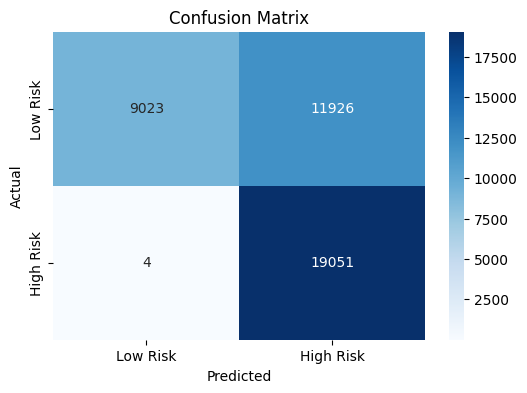

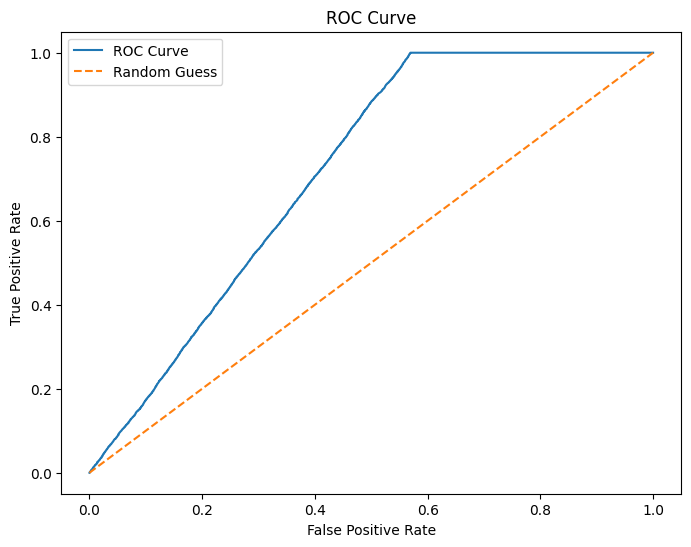

In [47]:
# Evaluate the model
model.eval()
y_true = []
y_pred = []
y_pred_proba = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        predicted = torch.sigmoid(outputs) >= 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())
        y_pred_proba.extend(torch.sigmoid(outputs).numpy())

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()
y_pred_proba = np.array(y_pred_proba).flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_proba)

print(f"Accuracy: {accuracy *100:.2f} %")
print(f"Precision: {precision *100:.2f} %")
print(f"Recall: {recall *100:.2f} %")
print(f"F1-Score: {f1 *100:.2f} %")
print(f"ROC AUC Score: {roc_auc:.2f}")

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Test the model with manual data

In [25]:
# manual_data = [
#     [99, 16, 36.654748, 95.011801, 118, 72, 41, 0, 96.006188, 1.833629],
#     [83, 12, 36.044191, 98.584497, 111, 84, 50, 0, 79.295332, 1.672735],
#     [79, 12, 36.884979, 95.987129, 130, 70, 22, 1, 79.869933, 1.922334],
#     [66, 15, 36.957178, 97.916267, 131, 77, 61, 1, 53.923400, 1.896381],
#     [72, 16, 36.8, 98, 120, 80, 20, 1, 78, 1.78]
# ]

# manual_data = np.array(manual_data)
# manual_data_scaled = scaler.transform(manual_data)
# manual_data_tensor = torch.tensor(manual_data_scaled, dtype=torch.float32)

# model.eval()
# with torch.no_grad():
#     outputs = model(manual_data_tensor)
#     predicted_probs = torch.sigmoid(outputs).numpy().flatten()
#     predicted_classes = (predicted_probs >= 0.5).astype(int)

# predicted_risk_categories = label_encoder.inverse_transform(predicted_classes)
# results_df = pd.DataFrame({
#     "Data Point": range(1, len(manual_data) + 1),
#     "Predicted Risk Category": predicted_risk_categories
# })
# print(results_df)

   Data Point Predicted Risk Category
0           1               High Risk
1           2                Low Risk
2           3                Low Risk
3           4               High Risk
4           5                Low Risk


## Save the model, scaler and encoder

In [48]:
model_save_path = "human_vital_sign_model2.pth"
torch.save(model.state_dict(), model_save_path)

scaler_save_path = "scaler2.pkl"
joblib.dump(scaler, scaler_save_path)

label_encoder_save_path = "label_encoder2.pkl"
joblib.dump(label_encoder, label_encoder_save_path)

['label_encoder2.pkl']